In [1]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

d:\Anaconda3\envs\myenv\lib\site-packages\google\api_core\_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.8.20). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
d:\Anaconda3\envs\myenv\lib\site-packages\google\auth\__init__.py:52: FutureWarning: You are using a Python version 3.8 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.8"), FutureWarning)
d:\Anaconda3\envs\myenv\lib\site-packages\google\oauth2\__init__.py:38: FutureWarning: You are using a Python version 3.8 past its end of life. Google will update google-auth with critical bug fixes on a best-effort bas

LOAD TRAINED U-NET MODEL

In [2]:
model = tf.keras.models.load_model("model/brain_tumor_unet_segmentation.h5")

IMG_SIZE = 256

IMAGE PATH (YOUR IMAGE)

In [3]:
img_path = r"C:\Users\User\OneDrive - NSBM\Desktop\Final Project\ML\testing_images_class\glioma\brisc2025_train_00007_gl_ax_t1.jpg"

PREPROCESS IMAGE

In [4]:
img = cv2.imread(img_path)

orig_img = img.copy()

img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

img_norm = img / 255.0

img_array = np.expand_dims(img_norm,axis=0)

PREDICT TUMOR MASK

In [5]:
pred = model.predict(img_array)

mask = pred[0,:,:,0]

mask = (mask > 0.5).astype(np.uint8)

1/1 [==============================] - 1s 879ms/step


HIGHLIGHT TUMOR REGION

In [6]:
overlay = img.copy()

overlay[mask==1] = [255,0,0]

DRAW BOUNDING BOX

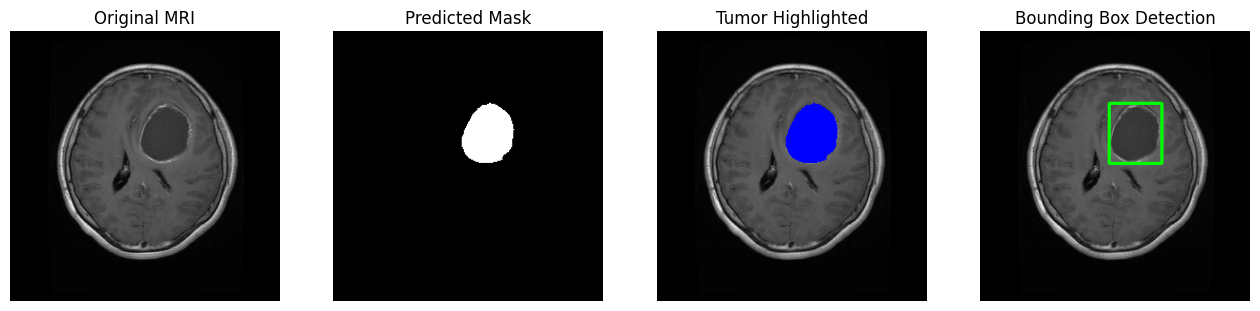

In [7]:
mask_uint8 = (mask*255).astype(np.uint8)

contours,_ = cv2.findContours(
    mask_uint8,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

bbox_img = img.copy()

for cnt in contours:

    x,y,w,h = cv2.boundingRect(cnt)

    cv2.rectangle(
        bbox_img,
        (x,y),
        (x+w,y+h),
        (0,255,0),
        2
    )

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(orig_img,cv2.COLOR_BGR2RGB))
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(mask,cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(cv2.cvtColor(overlay,cv2.COLOR_BGR2RGB))
plt.title("Tumor Highlighted")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(cv2.cvtColor(bbox_img,cv2.COLOR_BGR2RGB))
plt.title("Bounding Box Detection")
plt.axis("off")

plt.show()